In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_validate
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

In [ ]:
! wget -O iris.csv https://ocw.mit.edu/courses/15-097-prediction-machine-learning-and-statistics-spring-2012/89d88c5528513adc4002a1618ce2efb0_iris.csv

--2025-10-29 00:27:07--  https://ocw.mit.edu/courses/15-097-prediction-machine-learning-and-statistics-spring-2012/89d88c5528513adc4002a1618ce2efb0_iris.csv
Resolving ocw.mit.edu (ocw.mit.edu)... 151.101.130.133, 151.101.2.133, 151.101.66.133, ...
Connecting to ocw.mit.edu (ocw.mit.edu)|151.101.130.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4698 (4.6K) [text/csv]
Saving to: ‘iris.csv’

iris.csv            100%[===================>]   4.59K  --.-KB/s    in 0s      

2025-10-29 00:27:07 (54.5 MB/s) - ‘iris.csv’ saved [4698/4698]



In [ ]:
iris_names = ['sepal_length_cm',	'sepal_width_cm',	'petal_length_cm',	'petal_width_cm', 'species']
data = pd.read_csv('iris.csv', names=iris_names)
data

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sepal_length_cm  150 non-null    float64
 1   sepal_width_cm   150 non-null    float64
 2   petal_length_cm  150 non-null    float64
 3   petal_width_cm   150 non-null    float64
 4   species          150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


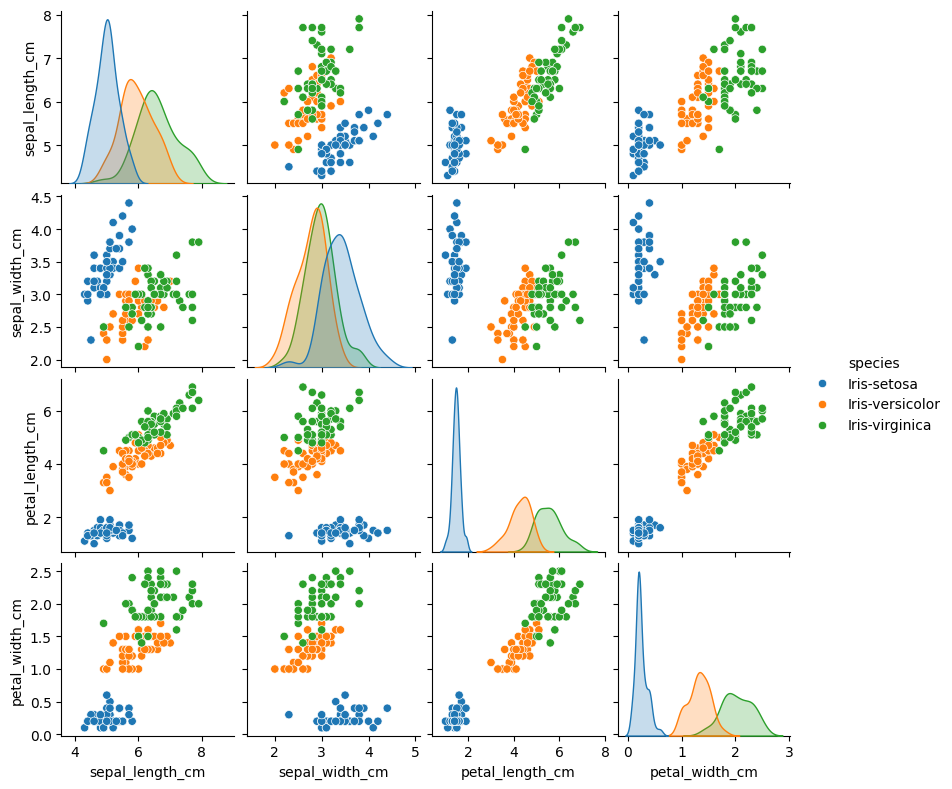

In [ ]:
sns.pairplot(data, hue='species', height=2);

In [ ]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(data['species'])
print(label_encoder.classes_)

['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [ ]:
data = data.drop(columns='species')
data

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [ ]:
pca = PCA()
pca.fit(data)
original_variance = pca.explained_variance_ratio_
print(original_variance)
print(np.cumsum(original_variance))

[0.92461621 0.05301557 0.01718514 0.00518309]
[0.92461621 0.97763178 0.99481691 1.        ]


In [ ]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2)),
    ('clf', LogisticRegression())
])
pipeline.steps

[('scaler', StandardScaler()),
 ('pca', PCA(n_components=2)),
 ('clf', LogisticRegression())]

In [ ]:
#Seperate train and test data
X_train, X_test, y_train, y_test = train_test_split(data.values, y, test_size = 0.3, random_state = 10)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(105, 4)
(45, 4)
(105,)
(45,)


In [ ]:
scores = cross_validate(pipeline, X_train, y_train, cv=3)
scores

{'fit_time': array([0.01606011, 0.00781941, 0.0076158 ]),
 'score_time': array([0.00223303, 0.00179243, 0.0017693 ]),
 'test_score': array([0.85714286, 0.82857143, 0.88571429])}

In [ ]:
scores['test_score'].mean()

np.float64(0.8571428571428571)

In [ ]:
clfs = [
    LogisticRegression(),
    SVC(),
    KNeighborsClassifier(n_neighbors=3),
    DecisionTreeClassifier(),
    RandomForestClassifier(),
    GradientBoostingClassifier()
]

for classifier in clfs:
    pipeline.set_params(clf=classifier)
    scores = cross_validate(pipeline, X_train, y_train, cv=3)
    print('---------------------------------')
    print(str(classifier))
    print('-----------------------------------')
    for key, values in scores.items():
            print(key,' mean ', values.mean())
            print(key,' std ', values.std())

---------------------------------
LogisticRegression()
-----------------------------------
fit_time  mean  0.006979465484619141
fit_time  std  0.0011529657737115613
score_time  mean  0.002178192138671875
score_time  std  0.0007566987542704078
test_score  mean  0.8571428571428571
test_score  std  0.023328473740792135
---------------------------------
SVC()
-----------------------------------
fit_time  mean  0.0036220550537109375
fit_time  std  6.802273289777725e-05
score_time  mean  0.0019915103912353516
score_time  std  0.00021983080795686083
test_score  mean  0.8857142857142857
test_score  std  0.02332847374079218
---------------------------------
KNeighborsClassifier(n_neighbors=3)
-----------------------------------
fit_time  mean  0.003441333770751953
fit_time  std  0.00020604083395086553
score_time  mean  0.0037027994791666665
score_time  std  0.00020445310280448414
test_score  mean  0.9047619047619047
test_score  std  0.01346870059402948
---------------------------------
Decision

In [ ]:
pipeline.set_params(clf=GradientBoostingClassifier())
pipeline.steps

[('scaler', StandardScaler()),
 ('pca', PCA(n_components=2)),
 ('clf', GradientBoostingClassifier())]

In [ ]:
GradientBoostingClassifier?

In [ ]:
cv_grid = GridSearchCV(pipeline, param_grid = {
    'clf__n_estimators': [2, 5, 10, 50, 100],
    'clf__max_depth': [1, 2, 3, 4, 5],
    'clf__max_features': ['sqrt', 'log2', None]

})

cv_grid.fit(X_train, y_train)

GridSearchCV(estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('pca', PCA(n_components=2)),
                                       ('clf', GradientBoostingClassifier())]),
             param_grid={'clf__max_depth': [1, 2, 3, 4, 5],
                         'clf__max_features': ['sqrt', 'log2', None],
                         'clf__n_estimators': [2, 5, 10, 50, 100]})

In [ ]:
cv_grid.best_params_

{'clf__max_depth': 3, 'clf__max_features': None, 'clf__n_estimators': 100}

In [ ]:
cv_grid.best_estimator_

Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=2)),
                ('clf', GradientBoostingClassifier())])

In [ ]:
cv_grid.best_score_

np.float64(0.9428571428571428)

In [ ]:
y_predict = cv_grid.predict(X_test)
accuracy = accuracy_score(y_test, y_predict)
print('Accuracy of the best classifier after CV is %.3f%%' % (accuracy*100))

Accuracy of the best classifier after CV is 95.556%
